### Binary and Ternary Classes in This Study Based on Mohs Hardness Values
Binary
0: (0.991, 5.5]
1: (5.5, 10.0]

Ternary
0: (0.991, 4.0]
1: (4.0, 7.0]
2: (7.0, 10.0]

### List of all Primary Features
- `allelectrons_Total`
- `density_Total`
- `allelectrons_Average`
- `val_e_Average`
- `atomicweight_Average`
- `ionenergy_Average`
- `el_neg_chi_Average`
- `R_vdw_element_Average`
- `R_cov_element_Average`
- `zaratio_Average`
- `density_Average`

### Train and Test Datasets
Train: Artificial_Crystals_Dataset.csv
Test: Mineral_Dataset_Supplementary_Info.csv

### ML Models Used
1. Binary RBF SVC
2. Ternary RBF SVC - OVO
3. Binary RF
4. Ternary RF - multiclass
5. Ternary RF - OVR: 0 versus 1, 2
6. Ternary RF - OVR: 1 versus 0, 2
7. Ternary RF - OVR: 2 versus 0, 1
8. Binary Matern SVC
9. Ternary Matern SVC - OVO

In [1]:
from pathlib import Path
import csv
from typing import Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_curve,
    auc,
)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [2]:
FEATURES = [
    "allelectrons_Total",
    "density_Total",
    "allelectrons_Average",
    "val_e_Average",
    "atomicweight_Average",
    "ionenergy_Average",
    "el_neg_chi_Average",
    "R_vdw_element_Average",
    "R_cov_element_Average",
    "zaratio_Average",
    "density_Average",
]

In [3]:
def binary_label_from_value(hardness: float) -> Optional[int]:
    if 0.991 < hardness <= 5.5:
        return 0
    if 5.5 < hardness <= 10.0:
        return 1
    return None


def ternary_label_from_value(hardness: float) -> Optional[int]:
    if 0.991 < hardness <= 4.0:
        return 0
    if 4.0 < hardness <= 7.0:
        return 1
    if 7.0 < hardness <= 10.0:
        return 2
    return None


def load_xy(csv_path: Path, hardness_column: str, label_fn=binary_label_from_value) -> Tuple[np.ndarray, np.ndarray]:
    x_rows = []
    y_rows = []
    with csv_path.open(newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                hardness = float(row[hardness_column])
                label_value = label_fn(hardness)
                if label_value is None:
                    continue
                feature_vector = [float(row[feature]) for feature in FEATURES]
            except (TypeError, ValueError, KeyError):
                continue
            x_rows.append(feature_vector)
            y_rows.append(label_value)
    return np.array(x_rows, dtype=float), np.array(y_rows, dtype=int)

In [ ]:
# Get path and load data
base_dir = Path.cwd()
if not (base_dir / "data").exists() and (base_dir.parent / "data").exists():
    base_dir = base_dir.parent

data_dir = base_dir / "data"
X, y = load_xy(data_dir / "Mineral_Dataset_Supplementary_Info.csv", "Hardness")
X_ternary, y_ternary = load_xy(
    data_dir / "Mineral_Dataset_Supplementary_Info.csv",
    "Hardness",
    label_fn=ternary_label_from_value,
)

### Replication Models 1-9 (separate blocks)
Run each model block below to compute `all_model_stats` and `all_class_stats` before plotting Figure 3 and Figure 4.

### Replication Outputs: Figure 3 (2x2) and Figure 4 (ROC)
This section reproduces the requested Figure 3 layout (excluding workflow) and Figure 4 ROC comparisons using 500 stratified splits and model IDs 1-9.

In [5]:
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.special import gamma as gamma_fn
from scipy.special import kv
from scipy.spatial.distance import cdist


def _resolve_gamma_value(gamma, X):
    if isinstance(gamma, str):
        if gamma == "scale":
            n_features = X.shape[1]
            x_var = float(np.var(X))
            if x_var <= 0.0:
                x_var = 1.0
            return 1.0 / (n_features * x_var)
        if gamma == "auto":
            return 1.0 / float(X.shape[1])
        raise ValueError(f"Unsupported gamma string: {gamma}")
    return float(gamma)


def _matern_kernel_matrix(X, Y, nu, gamma_value):
    r = cdist(X, Y, metric="euclidean")
    beta = 2.0 * np.sqrt(nu * gamma_value) * r
    factor = (2.0 ** (1.0 - nu)) / gamma_fn(nu)

    K = np.empty_like(beta, dtype=float)
    zero_mask = beta == 0
    K[zero_mask] = 1.0

    nonzero = ~zero_mask
    b = beta[nonzero]
    K[nonzero] = factor * (b**nu) * kv(nu, b)
    return K


class _MaternPrecomputedSVC(BaseEstimator, ClassifierMixin):
    def __init__(self, C, nu, gamma, probability, random_state):
        self.C = float(C)
        self.nu = float(nu)
        self.gamma = gamma
        self.probability = bool(probability)
        self.random_state = random_state

        self.classes_ = None
        self._svc = None
        self._X_train = None
        self._gamma_value = None

    def fit(self, X, y):
        self._gamma_value = _resolve_gamma_value(self.gamma, X)
        self._X_train = X
        K_train = _matern_kernel_matrix(X, X, nu=self.nu, gamma_value=self._gamma_value)
        self._svc = SVC(kernel="precomputed", C=self.C, probability=self.probability, random_state=self.random_state)
        self._svc.fit(K_train, y)
        self.classes_ = self._svc.classes_
        return self

    def predict(self, X):
        K = _matern_kernel_matrix(X, self._X_train, nu=self.nu, gamma_value=self._gamma_value)
        return self._svc.predict(K)

    def predict_proba(self, X):
        K = _matern_kernel_matrix(X, self._X_train, nu=self.nu, gamma_value=self._gamma_value)
        return self._svc.predict_proba(K)


def make_svc_rbf(probability, c, gamma, random_state):
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("svc", SVC(kernel="rbf", C=c, gamma=gamma, probability=probability, random_state=random_state)),
        ]
    )


def make_svc_matern(probability, c, nu, gamma, random_state):
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("svc", _MaternPrecomputedSVC(C=c, nu=nu, gamma=gamma, probability=probability, random_state=random_state)),
        ]
    )


def build_model_from_spec(spec, y_type, random_seed):
    probability = True
    family = spec["family"]
    kernel = spec.get("kernel")

    if family == "svc":
        if kernel == "rbf":
            return make_svc_rbf(probability=probability, c=float(spec["C"]), gamma=spec.get("gamma", "scale"), random_state=random_seed)
        if kernel == "matern":
            return make_svc_matern(probability=probability, c=float(spec["C"]), nu=float(spec["nu"]), gamma=spec.get("gamma", "scale"), random_state=random_seed)
        raise ValueError(f"Unsupported SVC kernel: {kernel}")

    if family == "rf":
        return RandomForestClassifier(n_estimators=500, random_state=random_seed, class_weight="balanced", n_jobs=-1)

    raise ValueError(f"Unknown model family: {family}")

MODEL_SPECS = {
    1: {"id": 1, "name": "binary_rbf_svc", "task": "binary", "family": "svc", "multiclass": "direct", "kernel": "rbf", "C": 10, "gamma": 1},
    2: {"id": 2, "name": "ternary_rbf_svc_ovo", "task": "ternary", "family": "svc", "multiclass": "ovo", "kernel": "rbf", "C": 10, "gamma": 1},
    3: {"id": 3, "name": "binary_rf", "task": "binary", "family": "rf", "multiclass": "direct"},
    4: {"id": 4, "name": "ternary_rf_multiclass", "task": "ternary", "family": "rf", "multiclass": "direct"},
    5: {"id": 5, "name": "ternary_rf_ovr_0_vs_12", "task": "ternary", "family": "rf", "multiclass": "ovr", "positive_class": 0},
    6: {"id": 6, "name": "ternary_rf_ovr_1_vs_02", "task": "ternary", "family": "rf", "multiclass": "ovr", "positive_class": 1},
    7: {"id": 7, "name": "ternary_rf_ovr_2_vs_01", "task": "ternary", "family": "rf", "multiclass": "ovr", "positive_class": 2},
    8: {"id": 8, "name": "binary_matern_svc", "task": "binary", "family": "svc", "multiclass": "direct", "kernel": "matern", "C": 10, "nu": 2.5},
    9: {"id": 9, "name": "ternary_matern_svc_ovo", "task": "ternary", "family": "svc", "multiclass": "ovo", "kernel": "matern", "C": 1, "nu": 1},
}

N_SPLITS = 500
RANDOM_STATE = 42

splitter_binary = StratifiedShuffleSplit(n_splits=N_SPLITS, train_size=2/3, test_size=1/3, random_state=RANDOM_STATE)
splitter_ternary = StratifiedShuffleSplit(n_splits=N_SPLITS, train_size=2/3, test_size=1/3, random_state=RANDOM_STATE)


def compute_macro_specificity_from_cm(cm: np.ndarray) -> float:
    specs = []
    for class_idx in range(cm.shape[0]):
        tp = cm[class_idx, class_idx]
        fp = cm[:, class_idx].sum() - tp
        fn = cm[class_idx, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
    return float(np.mean(specs))


def evaluate_model_over_splits(model_id: int):
    spec = MODEL_SPECS[model_id]
    task = spec["task"]

    if task == "binary":
        X_task, y_task = X, y
        split_iter = splitter_binary.split(X_task, y_task)
        labels = [0, 1]
    else:
        X_task, y_task = X_ternary, y_ternary
        split_iter = splitter_ternary.split(X_task, y_task)
        labels = [0, 1, 2]

    metric_series = {"precision": [], "recall": [], "accuracy": [], "f1": [], "specificity": []}
    class_recall_series = {0: [], 1: [], 2: []}
    class_specificity_series = {0: [], 1: [], 2: []}

    for train_index, test_index in split_iter:
        X_train, X_test = X_task[train_index], X_task[test_index]
        y_train_raw, y_test_raw = y_task[train_index], y_task[test_index]

        y_type = "binary"
        y_train, y_test = y_train_raw, y_test_raw

        if model_id in [5, 6, 7]:
            pos_class = spec["positive_class"]
            y_train = np.where(y_train_raw == pos_class, 0, 1)
            y_test = np.where(y_test_raw == pos_class, 0, 1)
            labels = [0, 1]
        elif task == "ternary":
            y_type = "ternary"
            labels = [0, 1, 2]

        estimator = build_model_from_spec(spec, y_type=y_type, random_seed=RANDOM_STATE)
        estimator.fit(X_train, y_train)
        y_pred = estimator.predict(X_test)

        precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)
        acc = accuracy_score(y_test, y_pred)

        if len(labels) == 2:
            tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=labels).ravel()
            spec_macro = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        else:
            cm = confusion_matrix(y_test, y_pred, labels=labels)
            spec_macro = compute_macro_specificity_from_cm(cm)

            recalls_per_class = precision_recall_fscore_support(y_test, y_pred, labels=labels, average=None, zero_division=0)[1]
            for class_idx in [0, 1, 2]:
                class_recall_series[class_idx].append(float(recalls_per_class[class_idx]))

            for class_idx in [0, 1, 2]:
                tp = cm[class_idx, class_idx]
                fp = cm[:, class_idx].sum() - tp
                fn = cm[class_idx, :].sum() - tp
                tn = cm.sum() - (tp + fp + fn)
                class_spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
                class_specificity_series[class_idx].append(float(class_spec))

        metric_series["precision"].append(float(precision))
        metric_series["recall"].append(float(recall))
        metric_series["accuracy"].append(float(acc))
        metric_series["f1"].append(float(f1))
        metric_series["specificity"].append(float(spec_macro))

    stats = {k: {"mean": float(np.mean(v)), "std": float(np.std(v, ddof=1))} for k, v in metric_series.items()}
    class_stats = {
        "recall": {k: {"mean": float(np.mean(v)), "std": float(np.std(v, ddof=1))} if len(v) else {"mean": np.nan, "std": np.nan} for k, v in class_recall_series.items()},
        "specificity": {k: {"mean": float(np.mean(v)), "std": float(np.std(v, ddof=1))} if len(v) else {"mean": np.nan, "std": np.nan} for k, v in class_specificity_series.items()},
    }
    return stats, class_stats


if "all_model_stats" not in globals():
    all_model_stats = {}
if "all_class_stats" not in globals():
    all_class_stats = {}

### Model 1 (binary RBF SVC)

In [6]:
stats, class_stats = evaluate_model_over_splits(1)
all_model_stats[1] = stats
all_class_stats[1] = class_stats
print(f"Model 1 F1={stats['f1']['mean']:.4f} ± {stats['f1']['std']:.4f}")

Model 1 F1=0.8657 ± 0.0219


### Model 2 (ternary RBF SVC OVO)

In [7]:
stats, class_stats = evaluate_model_over_splits(2)
all_model_stats[2] = stats
all_class_stats[2] = class_stats
print(f"Model 2 F1={stats['f1']['mean']:.4f} ± {stats['f1']['std']:.4f}")

Model 2 F1=0.8312 ± 0.0217


### Model 3 (binary RF)

In [8]:
stats, class_stats = evaluate_model_over_splits(3)
all_model_stats[3] = stats
all_class_stats[3] = class_stats
print(f"Model 3 F1={stats['f1']['mean']:.4f} ± {stats['f1']['std']:.4f}")

Model 3 F1=0.8578 ± 0.0218


### Model 4 (ternary RF multiclass)

In [9]:
stats, class_stats = evaluate_model_over_splits(4)
all_model_stats[4] = stats
all_class_stats[4] = class_stats
print(f"Model 4 F1={stats['f1']['mean']:.4f} ± {stats['f1']['std']:.4f}")

Model 4 F1=0.8354 ± 0.0215


### Model 5 (ternary RF OVR: 0 vs 1,2)

In [10]:
stats, class_stats = evaluate_model_over_splits(5)
all_model_stats[5] = stats
all_class_stats[5] = class_stats
print(f"Model 5 F1={stats['f1']['mean']:.4f} ± {stats['f1']['std']:.4f}")

Model 5 F1=0.8833 ± 0.0200


### Model 6 (ternary RF OVR: 1 vs 0,2)

In [11]:
stats, class_stats = evaluate_model_over_splits(6)
all_model_stats[6] = stats
all_class_stats[6] = class_stats
print(f"Model 6 F1={stats['f1']['mean']:.4f} ± {stats['f1']['std']:.4f}")

Model 6 F1=0.8494 ± 0.0205


### Model 7 (ternary RF OVR: 2 vs 0,1)

In [12]:
stats, class_stats = evaluate_model_over_splits(7)
all_model_stats[7] = stats
all_class_stats[7] = class_stats
print(f"Model 7 F1={stats['f1']['mean']:.4f} ± {stats['f1']['std']:.4f}")

Model 7 F1=0.9511 ± 0.0082


### Model 8 (binary Matern SVC)

In [13]:
stats, class_stats = evaluate_model_over_splits(8)
all_model_stats[8] = stats
all_class_stats[8] = class_stats
print(f"Model 8 F1={stats['f1']['mean']:.4f} ± {stats['f1']['std']:.4f}")

Model 8 F1=0.8506 ± 0.0226


### Model 9 (ternary Matern SVC OVO)

In [14]:
stats, class_stats = evaluate_model_over_splits(9)
all_model_stats[9] = stats
all_class_stats[9] = class_stats
print(f"Model 9 F1={stats['f1']['mean']:.4f} ± {stats['f1']['std']:.4f}")

if len(all_model_stats) == 9:
    print("All 9 model blocks computed.")

Model 9 F1=0.7828 ± 0.0241
All 9 model blocks computed.


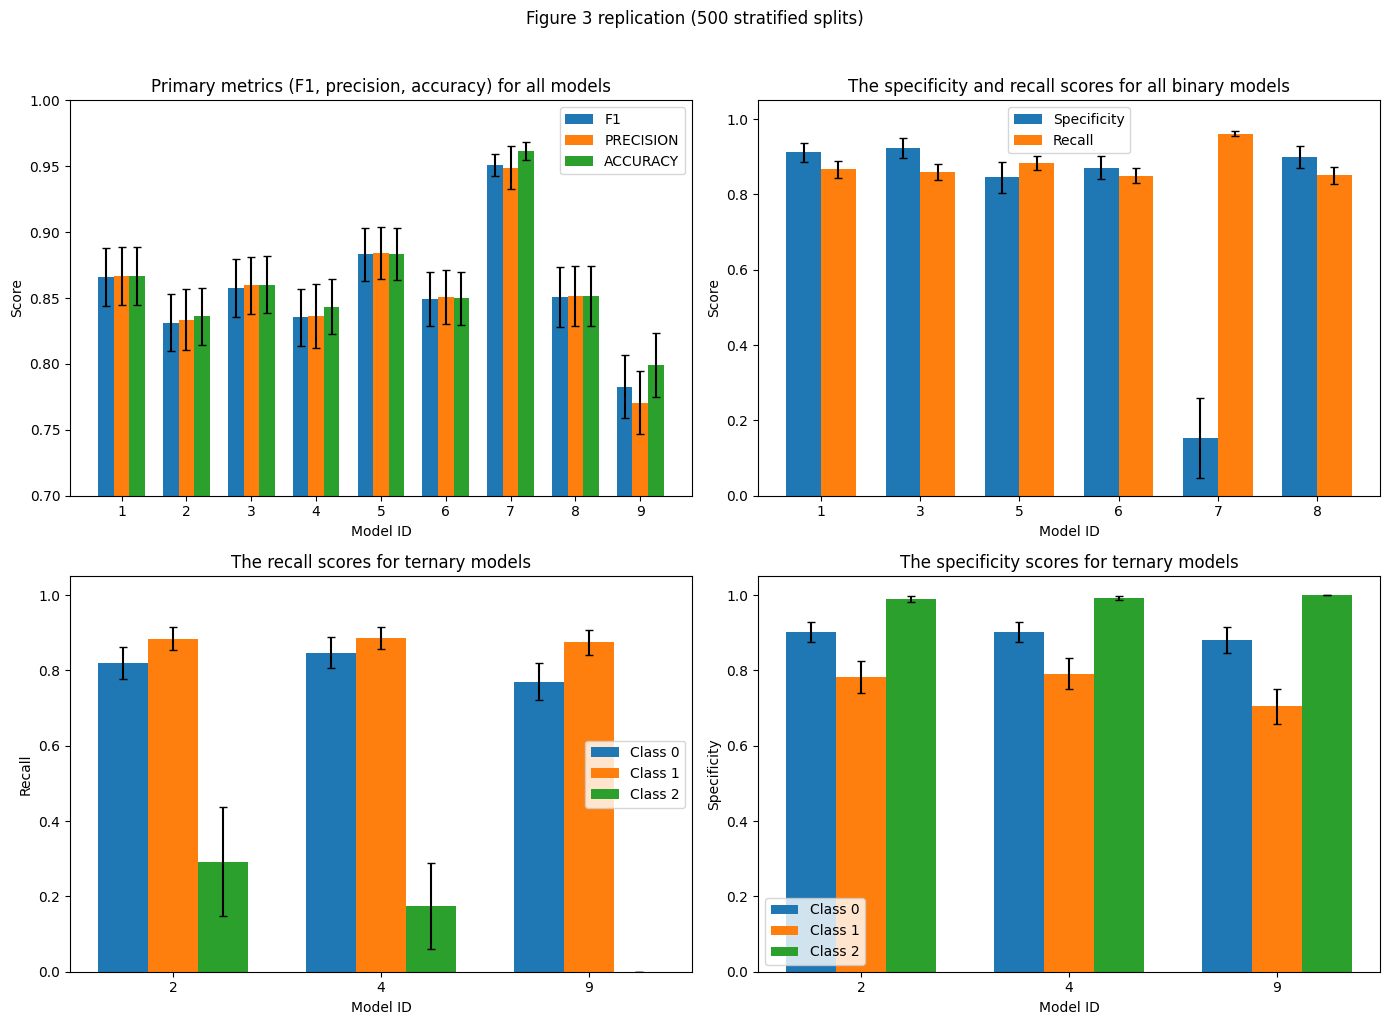

Saved Figure 3 to: outputs/figures/figure3_replication_2x2.png


In [15]:
# Figure 3 replication (workflow panel removed)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

model_ids_all = list(range(1, 10))
model_ids_binary = [1, 3, 5, 6, 7, 8]
model_ids_ternary = [2, 4, 9]

# (a) F1, Precision, Accuracy for model IDs 1-9
ax = axes[0, 0]
metrics_a = ["f1", "precision", "accuracy"]
x = np.arange(len(model_ids_all))
w = 0.24
for i, metric in enumerate(metrics_a):
    means = [all_model_stats[mid][metric]["mean"] for mid in model_ids_all]
    stds = [all_model_stats[mid][metric]["std"] for mid in model_ids_all]
    ax.bar(x + (i - 1) * w, means, width=w, yerr=stds, capsize=3, label=metric.upper())
ax.set_xticks(x)
ax.set_xticklabels(model_ids_all)
ax.set_ylim(0.7, 1.0)
ax.set_xlabel("Model ID")
ax.set_ylabel("Score")
ax.set_title("Primary metrics (F1, precision, accuracy) for all models")
ax.legend()

# (b) Specificity, Recall for model IDs 1,3,5,6,7,8
ax = axes[0, 1]
metrics_b = ["specificity", "recall"]
x = np.arange(len(model_ids_binary))
w = 0.35
for i, metric in enumerate(metrics_b):
    means = [all_model_stats[mid][metric]["mean"] for mid in model_ids_binary]
    stds = [all_model_stats[mid][metric]["std"] for mid in model_ids_binary]
    ax.bar(x + (i - 0.5) * w, means, width=w, yerr=stds, capsize=3, label=metric.capitalize())
ax.set_xticks(x)
ax.set_xticklabels(model_ids_binary)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Model ID")
ax.set_ylabel("Score")
ax.set_title("The specificity and recall scores for all binary models")
ax.legend()

# (c) Recall by class for ternary models 2,4,9
ax = axes[1, 0]
x = np.arange(len(model_ids_ternary))
w = 0.24
for class_idx in [0, 1, 2]:
    means = [all_class_stats[mid]["recall"][class_idx]["mean"] for mid in model_ids_ternary]
    stds = [all_class_stats[mid]["recall"][class_idx]["std"] for mid in model_ids_ternary]
    ax.bar(x + (class_idx - 1) * w, means, width=w, yerr=stds, capsize=3, label=f"Class {class_idx}")
ax.set_xticks(x)
ax.set_xticklabels(model_ids_ternary)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Model ID")
ax.set_ylabel("Recall")
ax.set_title("The recall scores for ternary models")
ax.legend()

# (d) Specificity by class for ternary models 2,4,9
ax = axes[1, 1]
x = np.arange(len(model_ids_ternary))
w = 0.24
for class_idx in [0, 1, 2]:
    means = [all_class_stats[mid]["specificity"][class_idx]["mean"] for mid in model_ids_ternary]
    stds = [all_class_stats[mid]["specificity"][class_idx]["std"] for mid in model_ids_ternary]
    ax.bar(x + (class_idx - 1) * w, means, width=w, yerr=stds, capsize=3, label=f"Class {class_idx}")
ax.set_xticks(x)
ax.set_xticklabels(model_ids_ternary)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Model ID")
ax.set_ylabel("Specificity")
ax.set_title("The specificity scores for ternary models")
ax.legend()

plt.suptitle("Figure 3 replication (500 stratified splits)", y=1.02)
plt.tight_layout()

outputs_dir = Path("outputs")
figures_dir = outputs_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
figure3_path = figures_dir / "figure3_replication_2x2.png"
plt.savefig(figure3_path, dpi=250, bbox_inches="tight")
plt.show()

print(f"Saved Figure 3 to: {figure3_path}")

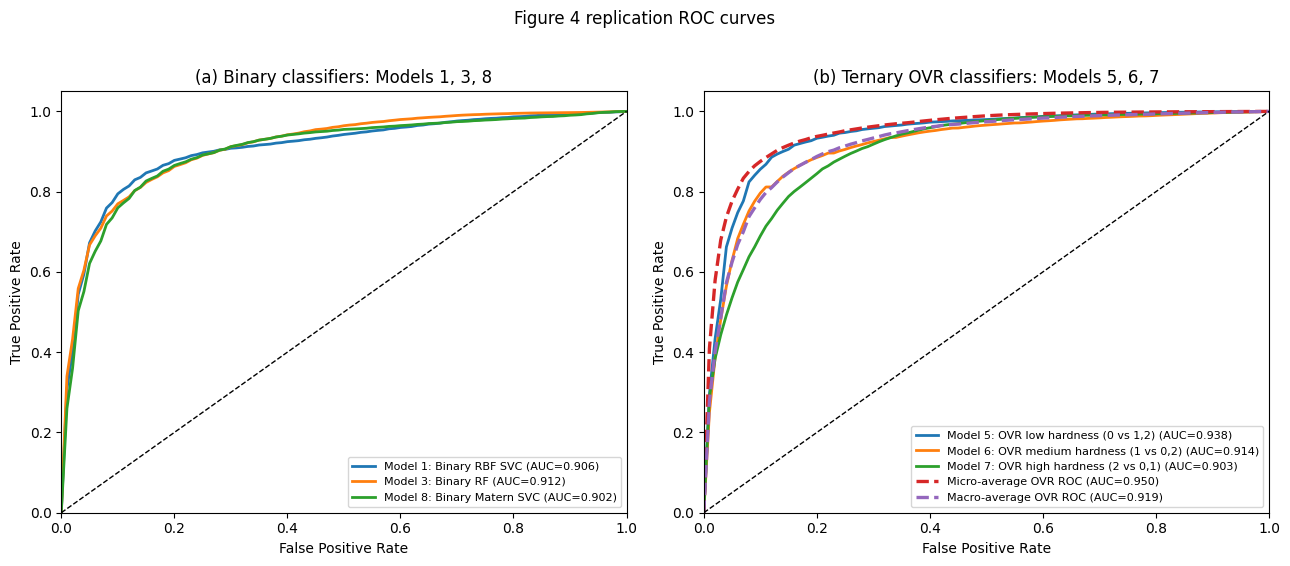

Saved Figure 4 to: outputs/figures/figure4_replication_roc.png


In [16]:
# Figure 4 replication
# (a) Binary models 1,3,8
# (b) Ternary OVR classifiers 5,6,7 + micro/macro averages


def mean_roc_over_splits(estimator_builder, X_data, y_data, splitter, positive_label=1):
    fpr_grid = np.linspace(0.0, 1.0, 101)
    tprs = []

    for train_idx, test_idx in splitter.split(X_data, y_data):
        X_train, X_test = X_data[train_idx], X_data[test_idx]
        y_train, y_test = y_data[train_idx], y_data[test_idx]

        est = estimator_builder()
        est.fit(X_train, y_train)
        scores = est.predict_proba(X_test)[:, 1] if hasattr(est, "predict_proba") else est.decision_function(X_test)

        fpr, tpr, _ = roc_curve((y_test == positive_label).astype(int), scores)
        interp_tpr = np.interp(fpr_grid, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    return fpr_grid, mean_tpr, auc(fpr_grid, mean_tpr)


def mean_ovr_curves_and_averages_over_splits(X_data, y_multiclass, splitter):
    """Compute models 5/6/7 ROC curves and micro/macro averages in one pass."""
    fpr_grid = np.linspace(0.0, 1.0, 101)

    tprs_5, tprs_6, tprs_7 = [], [], []
    micro_tprs, macro_tprs = [], []

    for train_idx, test_idx in splitter.split(X_data, y_multiclass):
        X_train, X_test = X_data[train_idx], X_data[test_idx]
        y_train, y_test = y_multiclass[train_idx], y_multiclass[test_idx]

        y_train_0 = np.where(y_train == 0, 0, 1)
        y_train_1 = np.where(y_train == 1, 0, 1)
        y_train_2 = np.where(y_train == 2, 0, 1)

        est5 = build_model_from_spec(MODEL_SPECS[5], y_type="binary", random_seed=RANDOM_STATE)
        est6 = build_model_from_spec(MODEL_SPECS[6], y_type="binary", random_seed=RANDOM_STATE)
        est7 = build_model_from_spec(MODEL_SPECS[7], y_type="binary", random_seed=RANDOM_STATE)

        est5.fit(X_train, y_train_0)
        est6.fit(X_train, y_train_1)
        est7.fit(X_train, y_train_2)

        s0 = est5.predict_proba(X_test)[:, 0]
        s1 = est6.predict_proba(X_test)[:, 0]
        s2 = est7.predict_proba(X_test)[:, 0]

        y0 = (y_test == 0).astype(int)
        y1 = (y_test == 1).astype(int)
        y2 = (y_test == 2).astype(int)

        # Per-model OVR curves
        for y_bin, scores, bucket in [(y0, s0, tprs_5), (y1, s1, tprs_6), (y2, s2, tprs_7)]:
            fpr_c, tpr_c, _ = roc_curve(y_bin, scores)
            tpr_interp = np.interp(fpr_grid, fpr_c, tpr_c)
            tpr_interp[0] = 0.0
            bucket.append(tpr_interp)

        # Micro/macro averages
        y_true_bin = np.column_stack([y0, y1, y2])
        score_mat = np.column_stack([s0, s1, s2])

        fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), score_mat.ravel())
        tpr_micro_interp = np.interp(fpr_grid, fpr_micro, tpr_micro)
        tpr_micro_interp[0] = 0.0
        micro_tprs.append(tpr_micro_interp)

        macro_tprs.append(np.mean([tprs_5[-1], tprs_6[-1], tprs_7[-1]], axis=0))

    def summarize(curves):
        mean_tpr = np.mean(curves, axis=0)
        mean_tpr[-1] = 1.0
        return fpr_grid, mean_tpr, auc(fpr_grid, mean_tpr)

    return {
        "m5": summarize(tprs_5),
        "m6": summarize(tprs_6),
        "m7": summarize(tprs_7),
        "micro": summarize(micro_tprs),
        "macro": summarize(macro_tprs),
    }


# Cache expensive ROC computation so reruns do not retrain everything.
if "figure4_cache" not in globals() or figure4_cache.get("n_splits") != N_SPLITS:
    splitter_for_roc_binary = StratifiedShuffleSplit(n_splits=N_SPLITS, train_size=2/3, test_size=1/3, random_state=RANDOM_STATE)
    splitter_for_roc_ternary = StratifiedShuffleSplit(n_splits=N_SPLITS, train_size=2/3, test_size=1/3, random_state=RANDOM_STATE)

    def builder_m1():
        return build_model_from_spec(MODEL_SPECS[1], y_type="binary", random_seed=RANDOM_STATE)

    def builder_m3():
        return build_model_from_spec(MODEL_SPECS[3], y_type="binary", random_seed=RANDOM_STATE)

    def builder_m8():
        return build_model_from_spec(MODEL_SPECS[8], y_type="binary", random_seed=RANDOM_STATE)

    roc_m1 = mean_roc_over_splits(builder_m1, X, y, splitter_for_roc_binary)
    roc_m3 = mean_roc_over_splits(builder_m3, X, y, splitter_for_roc_binary)
    roc_m8 = mean_roc_over_splits(builder_m8, X, y, splitter_for_roc_binary)

    ovr = mean_ovr_curves_and_averages_over_splits(X_ternary, y_ternary, splitter_for_roc_ternary)

    figure4_cache = {
        "n_splits": N_SPLITS,
        "roc_m1": roc_m1,
        "roc_m3": roc_m3,
        "roc_m8": roc_m8,
        "roc_m5": ovr["m5"],
        "roc_m6": ovr["m6"],
        "roc_m7": ovr["m7"],
        "roc_micro": ovr["micro"],
        "roc_macro": ovr["macro"],
    }

roc_m1 = figure4_cache["roc_m1"]
roc_m3 = figure4_cache["roc_m3"]
roc_m8 = figure4_cache["roc_m8"]
roc_m5 = figure4_cache["roc_m5"]
roc_m6 = figure4_cache["roc_m6"]
roc_m7 = figure4_cache["roc_m7"]
roc_micro = figure4_cache["roc_micro"]
roc_macro = figure4_cache["roc_macro"]

# Plot Figure 4
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
for (fpr, tpr, roc_auc), label in [
    (roc_m1, "Model 1: Binary RBF SVC"),
    (roc_m3, "Model 3: Binary RF"),
    (roc_m8, "Model 8: Binary Matern SVC"),
]:
    ax.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC={roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("(a) Binary classifiers: Models 1, 3, 8")
ax.legend(fontsize=8)

ax = axes[1]
for (fpr, tpr, roc_auc), label in [
    (roc_m5, "Model 5: OVR low hardness (0 vs 1,2)"),
    (roc_m6, "Model 6: OVR medium hardness (1 vs 0,2)"),
    (roc_m7, "Model 7: OVR high hardness (2 vs 0,1)"),
    (roc_micro, "Micro-average OVR ROC"),
    (roc_macro, "Macro-average OVR ROC"),
]:
    style = "--" if "average" in label else "-"
    width = 2.4 if "average" in label else 2.0
    ax.plot(fpr, tpr, linestyle=style, linewidth=width, label=f"{label} (AUC={roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("(b) Ternary OVR classifiers: Models 5, 6, 7")
ax.legend(fontsize=8)

plt.suptitle("Figure 4 replication ROC curves", y=1.02)
plt.tight_layout()

figure4_path = figures_dir / "figure4_replication_roc.png"
plt.savefig(figure4_path, dpi=250, bbox_inches="tight")
plt.show()

print(f"Saved Figure 4 to: {figure4_path}")

### Extension: Neural Network (MLP) for Ternary Hardness Prediction
This extension searches ANN architectures and regularization strengths using repeated stratified splits, then compares ANN performance to the baseline ternary models.

Saved comparison table to: outputs/results/ann_vs_methods_comparison.csv
ANN extension result: best ANN compared with Models 1-9


,model,f1_mean,accuracy_mean
0,Model 7,0.951069,0.961375
1,Model 5,0.883279,0.883548
2,Model 1,0.865724,0.866692
3,Model 3,0.857780,0.860163
4,Model 8,0.850588,0.851500
5,Model 6,0.849412,0.849654
6,Model 4,0.835376,0.843490
7,Model 2,0.831188,0.836231
8,Model 9,0.782831,0.799413
9,Best ANN,0.720909,0.733678


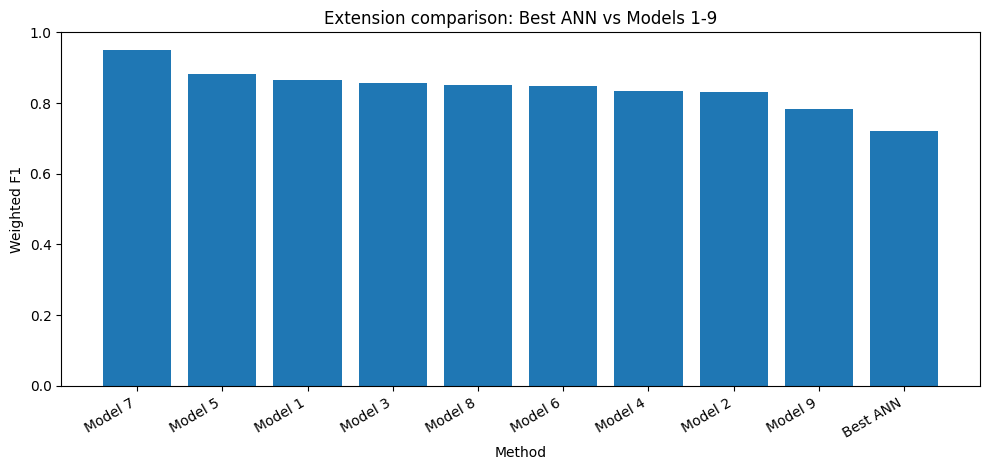

Saved comparison figure to: outputs/figures/ann_vs_methods_f1.png


In [25]:
# Extension goal: compare ANN vs existing methods (not architecture exploration)
ANN_SPLITS = 200
ann_splitter = StratifiedShuffleSplit(
    n_splits=ANN_SPLITS,
    train_size=2 / 3,
    test_size=1 / 3,
    random_state=42,
)

# Keep a compact candidate set, then compare best ANN against baselines
ann_candidates = [
    {"hidden_layer_sizes": (32,), "alpha": 1e-4},
    {"hidden_layer_sizes": (64,), "alpha": 1e-4},
    {"hidden_layer_sizes": (64, 32), "alpha": 1e-4},
    {"hidden_layer_sizes": (64, 32), "alpha": 1e-3},
]


def evaluate_ann_candidate(hidden_layer_sizes, alpha):
    series = {"precision": [], "recall": [], "accuracy": [], "f1": [], "specificity": []}

    for train_idx, test_idx in ann_splitter.split(X_ternary, y_ternary):
        X_train, X_test = X_ternary[train_idx], X_ternary[test_idx]
        y_train, y_test = y_ternary[train_idx], y_ternary[test_idx]

        ann_model = Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "mlp",
                    MLPClassifier(
                        hidden_layer_sizes=hidden_layer_sizes,
                        alpha=alpha,
                        activation="relu",
                        solver="adam",
                        learning_rate="adaptive",
                        early_stopping=True,
                        max_iter=3000,
                        random_state=42,
                    ),
                ),
            ]
        )

        ann_model.fit(X_train, y_train)
        y_pred = ann_model.predict(X_test)

        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0,
        )
        accuracy = accuracy_score(y_test, y_pred)

        cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
        per_class_specificity = []
        for class_idx in range(cm.shape[0]):
            tp = cm[class_idx, class_idx]
            fp = cm[:, class_idx].sum() - tp
            fn = cm[class_idx, :].sum() - tp
            tn = cm.sum() - (tp + fp + fn)
            class_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            per_class_specificity.append(class_specificity)
        specificity = float(np.mean(per_class_specificity))

        series["precision"].append(float(precision))
        series["recall"].append(float(recall))
        series["accuracy"].append(float(accuracy))
        series["f1"].append(float(f1))
        series["specificity"].append(float(specificity))

    return {
        metric: {
            "mean": float(np.mean(values)),
            "std": float(np.std(values, ddof=1)),
        }
        for metric, values in series.items()
    }


# Train/evaluate ANN candidates and pick the best by weighted F1
if "ann_results_df" not in globals() or ann_results_df.empty:
    ann_rows = []
    for cand in ann_candidates:
        stats = evaluate_ann_candidate(cand["hidden_layer_sizes"], cand["alpha"])
        ann_rows.append(
            {
                "model": f"ANN {cand['hidden_layer_sizes']} a={cand['alpha']}",
                "f1_mean": stats["f1"]["mean"],
                "f1_std": stats["f1"]["std"],
                "accuracy_mean": stats["accuracy"]["mean"],
                "accuracy_std": stats["accuracy"]["std"],
                "recall_mean": stats["recall"]["mean"],
                "recall_std": stats["recall"]["std"],
                "specificity_mean": stats["specificity"]["mean"],
                "specificity_std": stats["specificity"]["std"],
            }
        )
    ann_results_df = pd.DataFrame(ann_rows).sort_values("f1_mean", ascending=False).reset_index(drop=True)

best_ann = ann_results_df.iloc[0]

# Compare best ANN directly against the existing methods from Figure 3 stats
if "all_model_stats" not in globals():
    raise RuntimeError("Run the Figure 3 stats cell first so all_model_stats is available.")

comparison_rows = []
for mid in range(1, 10):
    comparison_rows.append(
        {
            "model": f"Model {mid}",
            "f1_mean": all_model_stats[mid]["f1"]["mean"],
            "accuracy_mean": all_model_stats[mid]["accuracy"]["mean"],
        }
    )
comparison_rows.append(
    {
        "model": "Best ANN",
        "f1_mean": float(best_ann["f1_mean"]),
        "accuracy_mean": float(best_ann["accuracy_mean"]),
    }
)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values("f1_mean", ascending=False).reset_index(drop=True)

# Save report-ready extension outputs
outputs_results_dir = Path("outputs") / "results"
outputs_results_dir.mkdir(parents=True, exist_ok=True)
comparison_csv_path = outputs_results_dir / "ann_vs_methods_comparison.csv"
comparison_df.to_csv(comparison_csv_path, index=False)

print(f"Saved comparison table to: {comparison_csv_path}")
print("ANN extension result: best ANN compared with Models 1-9")
display(comparison_df)

# Plot F1 comparison
plt.figure(figsize=(10, 4.8))
plt.bar(comparison_df["model"], comparison_df["f1_mean"])
plt.ylim(0.0, 1.0)
plt.ylabel("Weighted F1")
plt.xlabel("Method")
plt.title("Extension comparison: Best ANN vs Models 1-9")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
ann_compare_fig = Path("outputs") / "figures" / "ann_vs_methods_f1.png"
plt.savefig(ann_compare_fig, dpi=250, bbox_inches="tight")
plt.show()
print(f"Saved comparison figure to: {ann_compare_fig}")

### Extension (continued): 9-class Mohs hardness prediction
Use **9 classes** (no separate label for Mohs 10 only):

- **Class 0:** \(0.991 < h < 2\)
- **Classes 1–7:** \(h \in [m, m{+}1)\) for \(m = 2,\ldots,8\) (Mohs 2 … 8)
- **Class 8:** \(9 \le h \le 10\) (Mohs 9 and 10 merged into one high-hardness bucket)

We train **Random Forest** with `class_weight="balanced"` and report **accuracy** and **macro F1** over repeated stratified splits. Adjust `N_SPLITS_9` if runtime is an issue.

9-class label distribution:
  class 0 (Mohs bucket): n=43
  class 1 (Mohs bucket): n=108
  class 2 (Mohs bucket): n=86
  class 3 (Mohs bucket): n=41
  class 4 (Mohs bucket): n=188
  class 5 (Mohs bucket): n=121
  class 6 (Mohs bucket): n=29
  class 7 (Mohs bucket): n=3
  class 8 (Mohs bucket): n=3

Random Forest — 9-class Mohs prediction
  Accuracy:  0.6219 ± 0.0298
  Macro F1:  0.4415 ± 0.0350


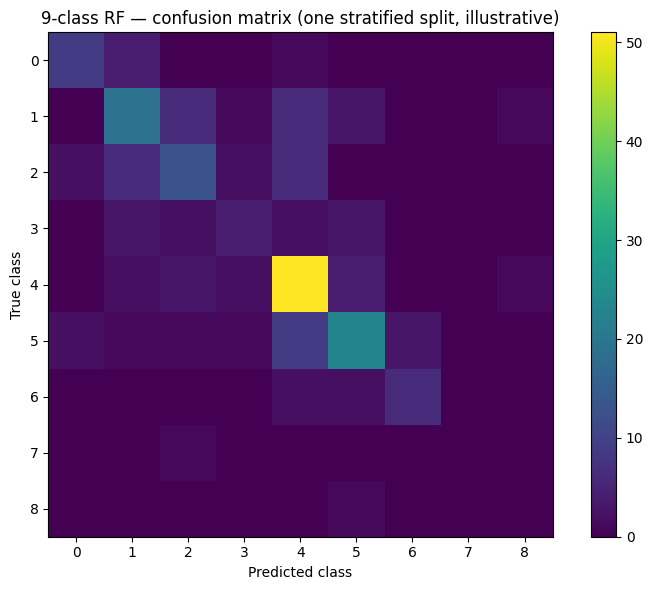

In [18]:
def mohs_nine_class_from_value(hardness: float) -> Optional[int]:
    """
    Class 0: (0.991, 2)
    Classes 1–7: [m, m+1) for m = 2..8  → Mohs 2..8
    Class 8: [9, 10]
    """
    if not (0.991 < hardness <= 10.0):
        return None
    if hardness < 2.0:
        return 0
    if hardness >= 9.0:
        return 8
    return int(hardness) - 1


X_9, y_9 = load_xy(
    data_dir / "Mineral_Dataset_Supplementary_Info.csv",
    "Hardness",
    label_fn=mohs_nine_class_from_value,
)

classes_9, counts_9 = np.unique(y_9, return_counts=True)
print("9-class label distribution:")
for c, n in zip(classes_9, counts_9):
    print(f"  class {c} (Mohs bucket): n={n}")

if np.any(counts_9 < 2):
    print(
        "\nWarning: at least one class has <2 samples — stratified CV may fail. "
        "Merge adjacent bins or use fewer splits."
    )

N_SPLITS_9 = 200
splitter_9 = StratifiedShuffleSplit(
    n_splits=N_SPLITS_9,
    train_size=2 / 3,
    test_size=1 / 3,
    random_state=RANDOM_STATE,
)

rf_9 = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1,
)

acc_scores, f1_macro_scores = [], []
for train_idx, test_idx in splitter_9.split(X_9, y_9):
    X_tr, X_te = X_9[train_idx], X_9[test_idx]
    y_tr, y_te = y_9[train_idx], y_9[test_idx]
    rf_9.fit(X_tr, y_tr)
    y_pred = rf_9.predict(X_te)
    acc_scores.append(accuracy_score(y_te, y_pred))
    f1_macro_scores.append(
        f1_score(y_te, y_pred, average="macro", zero_division=0)
    )

print("\nRandom Forest — 9-class Mohs prediction")
print(f"  Accuracy:  {np.mean(acc_scores):.4f} ± {np.std(acc_scores, ddof=1):.4f}")
print(f"  Macro F1:  {np.mean(f1_macro_scores):.4f} ± {np.std(f1_macro_scores, ddof=1):.4f}")

# Illustrative confusion matrix on one stratified split
rf_9_full = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1,
)
idx_tr, idx_te = next(StratifiedShuffleSplit(n_splits=1, train_size=2 / 3, test_size=1 / 3, random_state=RANDOM_STATE).split(X_9, y_9))
rf_9_full.fit(X_9[idx_tr], y_9[idx_tr])
y_hat = rf_9_full.predict(X_9[idx_te])
cm = confusion_matrix(y_9[idx_te], y_hat, labels=list(range(9)))
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("9-class RF — confusion matrix (one stratified split, illustrative)")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.colorbar()
plt.tight_layout()
plt.show()

### Extension (continued): fixed external test set (artificial crystals)
Train on **natural minerals** (`Mineral_Dataset_Supplementary_Info.csv`) and report **test accuracy** (and F1) on **artificial crystals** (`Artificial_Crystals_Dataset.csv`). The artificial CSV uses the hardness column **`Hardness (Mohs)`**; the mineral CSV uses **`Hardness`**. Run the cell that defines `MODEL_SPECS`, `build_model_from_spec`, and label helpers first.

Train (natural): n=622  |  Test (artificial): n=52

Natural train → artificial test (saved CSV):
model_id                    name  test_accuracy  test_f1_weighted  test_f1_macro  n_test
       5  ternary_rf_ovr_0_vs_12       0.903846          0.905343       0.860440      52
       7  ternary_rf_ovr_2_vs_01       0.903846          0.884729       0.617084      52
       3               binary_rf       0.826923          0.825554       0.823729      52
       4   ternary_rf_multiclass       0.788462          0.774114       0.628343      52
       9  ternary_matern_svc_ovo       0.788462          0.743987       0.520253      52
       1          binary_rbf_svc       0.769231          0.769231       0.767857      52
       6  ternary_rf_ovr_1_vs_02       0.750000          0.752027       0.711481      52
       8       binary_matern_svc       0.750000          0.750277       0.749908      52
       2     ternary_rbf_svc_ovo       0.730769          0.738009       0.581137      52
     ANN mlp_

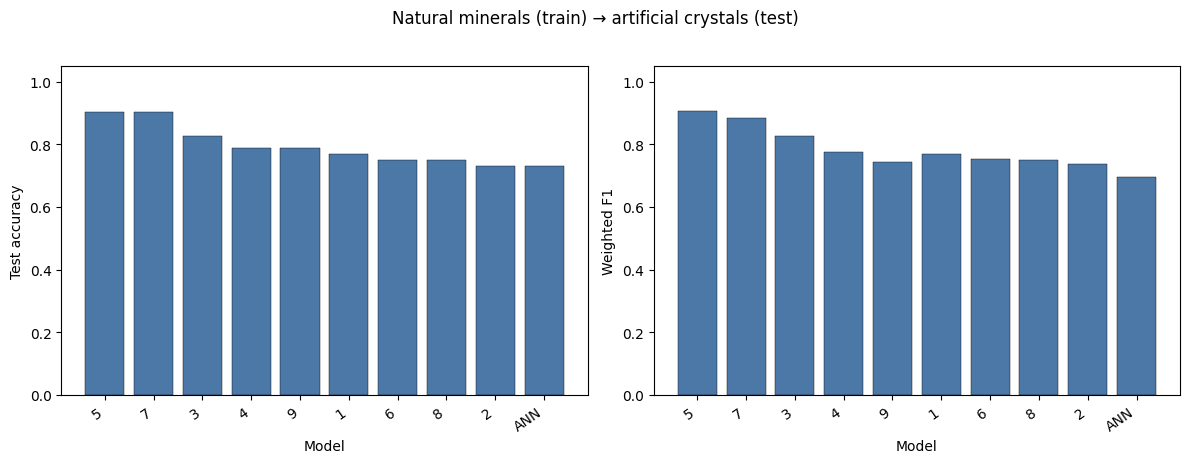


Saved figure: outputs/figures/natural_train_artificial_test_metrics.png
Saved CSV: outputs/results/natural_train_artificial_test_metrics.csv


In [21]:
def load_xy_col(csv_path: Path, hardness_column: str, label_fn) -> Tuple[np.ndarray, np.ndarray]:
    """Same as load_xy but hardness column name is explicit (mineral vs artificial CSV)."""
    x_rows = []
    y_rows = []
    with csv_path.open(newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                hardness = float(row[hardness_column])
                label_value = label_fn(hardness)
                if label_value is None:
                    continue
                feature_vector = [float(row[feature]) for feature in FEATURES]
            except (TypeError, ValueError, KeyError):
                continue
            x_rows.append(feature_vector)
            y_rows.append(label_value)
    return np.array(x_rows, dtype=float), np.array(y_rows, dtype=int)


train_csv = data_dir / "Mineral_Dataset_Supplementary_Info.csv"
test_csv = data_dir / "Artificial_Crystals_Dataset.csv"
col_train = "Hardness"
col_test = "Hardness (Mohs)"

# Natural = train, artificial = test (paper-style holdout)
X_nat_bin, y_nat_bin = load_xy_col(train_csv, col_train, binary_label_from_value)
X_art_bin, y_art_bin = load_xy_col(test_csv, col_test, binary_label_from_value)

X_nat_ter, y_nat_ter = load_xy_col(train_csv, col_train, ternary_label_from_value)
X_art_ter, y_art_ter = load_xy_col(test_csv, col_test, ternary_label_from_value)

print(f"Train (natural): n={len(y_nat_ter)}  |  Test (artificial): n={len(y_art_ter)}")

rows = []
for model_id in range(1, 10):
    spec = MODEL_SPECS[model_id]
    task = spec["task"]

    if task == "binary":
        X_tr, y_tr = X_nat_bin, y_nat_bin
        X_te, y_te = X_art_bin, y_art_bin
        y_type = "binary"
    else:
        X_tr, y_tr = X_nat_ter, y_nat_ter
        X_te, y_te = X_art_ter, y_art_ter
        if spec.get("family") == "rf" and spec.get("multiclass") == "ovr":
            pos = int(spec["positive_class"])
            y_tr = np.where(y_tr == pos, 0, 1)
            y_te = np.where(y_te == pos, 0, 1)
            y_type = "binary"
        else:
            y_type = "ternary"

    est = build_model_from_spec(spec, y_type=y_type, random_seed=RANDOM_STATE)
    est.fit(X_tr, y_tr)
    y_pred = est.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    n_classes = len(np.unique(np.concatenate([y_te, y_pred])))
    if n_classes < 2:
        f1w = float("nan")
        f1m = float("nan")
    else:
        f1w = f1_score(y_te, y_pred, average="weighted", zero_division=0)
        f1m = f1_score(y_te, y_pred, average="macro", zero_division=0)
    rows.append(
        {
            "model_id": model_id,
            "name": spec["name"],
            "test_accuracy": acc,
            "test_f1_weighted": f1w,
            "test_f1_macro": f1m,
            "n_test": len(y_te),
        }
    )

# Best ANN (ternary), same train/test split as paper extension
ann_ext = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                alpha=1e-4,
                activation="relu",
                solver="adam",
                learning_rate="adaptive",
                early_stopping=True,
                max_iter=3000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
ann_ext.fit(X_nat_ter, y_nat_ter)
y_ann = ann_ext.predict(X_art_ter)
rows.append(
    {
        "model_id": "ANN",
        "name": "mlp_ternary_64_32_a1e-4",
        "test_accuracy": accuracy_score(y_art_ter, y_ann),
        "test_f1_weighted": f1_score(y_art_ter, y_ann, average="weighted", zero_division=0),
        "test_f1_macro": f1_score(y_art_ter, y_ann, average="macro", zero_division=0),
        "n_test": len(y_art_ter),
    }
)

df_ext = pd.DataFrame(rows).sort_values("test_accuracy", ascending=False)

if "all_model_stats" not in globals():
    raise RuntimeError("Run the Figure 3 stats cell first so all_model_stats is available.")
if "best_ann" not in globals():
    raise RuntimeError("Run the ANN extension cell first so best_ann is available.")


def _cv_f1(mid):
    if mid == "ANN":
        return float(best_ann["f1_mean"])
    return float(all_model_stats[int(mid)]["f1"]["mean"])


def _cv_acc(mid):
    if mid == "ANN":
        return float(best_ann["accuracy_mean"])
    return float(all_model_stats[int(mid)]["accuracy"]["mean"])


compare_rows = []
for mid in list(range(1, 10)) + ["ANN"]:
    sub = df_ext[df_ext["model_id"] == mid]
    if sub.empty:
        continue
    r = sub.iloc[0]
    compare_rows.append(
        {
            "model_id": mid,
            "name": r["name"],
            "cv_f1_weighted_mean": _cv_f1(mid),
            "cv_accuracy_mean": _cv_acc(mid),
            "test_accuracy": r["test_accuracy"],
            "test_f1_weighted": r["test_f1_weighted"],
            "test_f1_macro": r["test_f1_macro"],
            "n_test": r["n_test"],
        }
    )
df_compare = pd.DataFrame(compare_rows)

out_path = Path("outputs") / "results" / "natural_train_artificial_test_metrics.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
df_compare.to_csv(out_path, index=False)

print("\nNatural (replication CV) vs natural train → artificial test (saved CSV):")
print(df_compare.to_string(index=False))

x = np.arange(len(df_compare))
labels = [str(m) for m in df_compare["model_id"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
axes[0].bar(x, df_compare["cv_f1_weighted_mean"], color="#4C78A8", edgecolor="black", linewidth=0.3)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=35, ha="right")
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Weighted F1")
axes[0].set_xlabel("Model")
axes[0].set_title("Natural minerals (replication CV)")

axes[1].bar(x, df_compare["test_f1_weighted"], color="#F58518", edgecolor="black", linewidth=0.3)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=35, ha="right")
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Weighted F1")
axes[1].set_xlabel("Model")
axes[1].set_title("Artificial crystals (holdout test)")

fig.suptitle("In-domain vs domain shift: weighted F1", y=1.02)
plt.tight_layout()
fig_path = Path("outputs") / "figures" / "natural_train_artificial_test_metrics.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=250, bbox_inches="tight")
plt.show()
print(f"\nSaved figure: {fig_path}")
print(f"Saved CSV: {out_path}")